# CSC_52081_EP - Lab 01

Intelligent decision making involves several components. Today we study, in the context of a toy (low-dimensional, synthetic) example: *perception* (observation), *knowledge* (representation), *reasoning* (inference), *acting* (decision-making), and *learning*. Using probabalistic tools covered in the lecture (Bayesian networks, marginalization, ...), the objective is to design a decision-making agent , i.e., an agent that maximizes its expected reward. 

We will be dealing with a partially observed Markov process (POMP) where decisions are estimations; we will not cover sequential decision making today. The underlying state is denoted $s_t$, and the observation $o_t$; at time $t$. Even though the mouse itself can be considered an agent, this -- for us -- is just a part of the environment, part of the POMP. Our agent (the 'ego' agent) is only a current-state estimator (i.e., a prescriptive system -- it prescribes where to find the mouse, but not a sequential-decision making system, as estimates cannot affect the future); with the 'reward' is the prediction accuracy. At time $t$, the observation sequence is $o_0,\ldots,o_t$.

### Instructions

Work your way through the notebook, and provide code where indicated to complete the tasks where indicated by `#TODO`. 

First, we're going to import the environment, `numpy` and some utility functions/classes that we will use. make sure the `environment.py` is in your working directory.

In [1]:
import numpy as np
import pandas as pd

from IPython.display import display

from envs.mouse_grid import *
from util import evaluate

## Task 0: Understand the Toy Scenario.

Consider a room divided into a number of square tiles. A mouse is in the room, you want to know where it is. However, the room is dark. You have to rely on auditory information only -- the volume of the sound depends on what tile the mouse is on. A mouse enters the room (at $t=0$, always at $s_0 = 1$). The objective is to predict where the mouse is at a given time $t$; i.e., to predict the square or state of the mouse $s_t$, providied observations obtained so far. The reward for the prediction at time $t$ is $r_t = 1(\hat s_t = s_t)$ where $\hat s_t$ the prediction.

Here we see the scenario. Unpassable tiles are filled as black. The marker marks the mouse's position. 

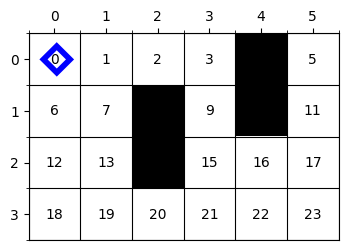

In [2]:
proc = MouseProcess()
o, _ = proc.reset()
fig, ax = plt.subplots(figsize=[4, 3])
draw(proc.env.G, s=proc.env.s, a=None, ax=ax, L=np.arange(proc.env.n_states).reshape(proc.env.G.shape).astype(int))
plt.show()

Each tile will create noise at a volume $\mathcal{N(o_t \mid \mu_s, \sigma)}$ with $\sigma=0.1$ and $\mu_s$ as shown below (for each gridsquare $s$; excepting the inaccessible tiles): 

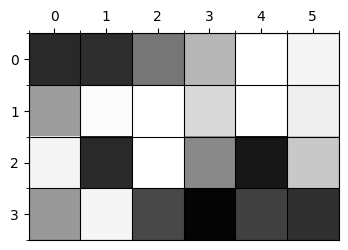

In [3]:
fig, ax = plt.subplots(figsize=[4, 3])
draw(proc.env.P.reshape(proc.env.G.shape), ax=ax)
plt.show()

The mouse moves from $s_{t-1}$ to $s_t$ with probability $P(s_{t} \mid s_{t-1})$ (namely, uniformly randomly, according to movement possibilities). We see $P(S_{t} \mid s_{t-1} = s)$ in the following (with darker shades indicating higher probability). You can change `s` (as suggested for e.g., `s`=16 in the following code to view transition probabilities for any state. 

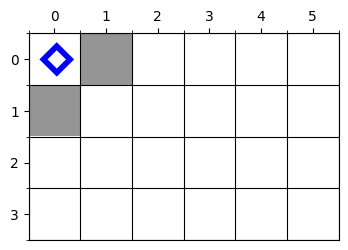

In [4]:
fig, ax = plt.subplots(figsize=[4, 3])
draw(proc.env.T[proc.env.s].reshape(proc.env.G.shape), s=proc.env.s, ax=ax)
#draw(proc.env.T[16].reshape(proc.env.G.shape), s=16, ax=ax)
plt.show()

Running the POMP means letting the mouse move freely and then figuring out where it is. Remember: we don't observe its position $s_t$ directly, rather only the observations $o_t \sim \mathcal{N}(\cdot \mid \mu_s, \sigma)$: 

In [5]:
o_seq = [proc.reset()[0]]
T = 10
for t in range(1,T):
    o_seq.append(proc.step()[0])

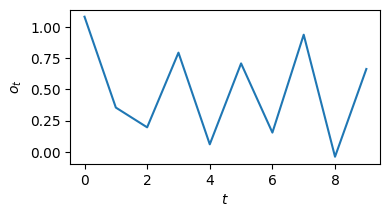

In [6]:
plt.figure(figsize=[4,2])
plt.plot(range(T), o_seq)
plt.xlabel("$t$")
plt.ylabel("$o_t$")
plt.show()

All the tasks in this exercise are about finding out where the mouse is at time $t$; i.e., $P(S_t | o_1,\ldots,o_t)$. 

We emit a prediction $\hat s_t$ at each timestep $t$, if we are correct, we obtain a reward of 1. The goal is to accumulate as much reward as possible over an episode of arbitrary length $T$. 

Guessing randomly where the mouse is, is quite innefective, as we see in the following (the `<code style="color : red">x</code>` symbol represents our prediction; the estimated state, $\hat s_t$): 

In [7]:
def random_estimator(proc, observations):
    return proc.state_space.sample(), None

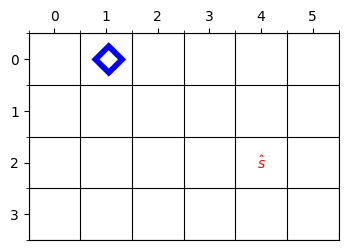

In [8]:
o_seq = [proc.reset()[0]]
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
sest, P_S = random_estimator(proc, o_seq)
fig, ax = plt.subplots(figsize=[4, 3])
draw(np.zeros_like(proc.env.G), ax=ax, s=proc.env.s, s_est=sest)
plt.show()

The following function will evaluate our estimator over `N` trajectories of length `T`. 

In [9]:
# Evaluate N episodes, over T timesteps.
res = evaluate(proc, random_estimator, N=100, T=10)
display(pd.DataFrame([res], index=["Random Estimator"]))

,average reward per episode,average time per estimator call
Random Estimator,0.41,0.000002


 
Estimating the current location based only on the current observation: 
$$p(s_T = s \mid o_T)$$

Note the access to `P_O(o_t, s_t)` which provides:
$$
    P( O_t = o_t | S_t = s_t)
$$

Note the estimator provides also (first argument returned) $$\hat s = \argmax_s P(S_T = s | \cdots )$$. 

In [10]:
def last_obs_estimator(proc, observations):
    """
    Compute P(S_t | o_t) assuming uniform prior over states.
    """
    n_states = proc.n_states
    probs = np.zeros(n_states)
    o_t = observations[-1]

    for s in range(n_states):
        probs[s] = proc.P_O(o_t, s)
    P_S = probs / probs.sum()
    return np.argmax(P_S), P_S

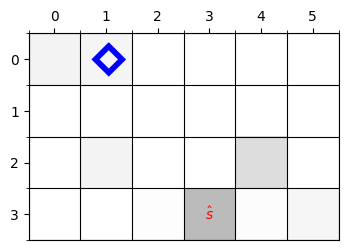

In [11]:
o_seq = [proc.reset()[0]]
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
sest, P_S = last_obs_estimator(proc, o_seq)
fig, ax = plt.subplots(figsize=[4, 3])
draw(P_S.reshape(proc.env.G.shape), ax=ax, s=proc.env.s, s_est=sest)
plt.show()

In [12]:
res = evaluate(proc, last_obs_estimator, N=100, T=10)
display(pd.DataFrame([res], index=["Naive Estimator"]))

,average reward per episode,average time per estimator call
Naive Estimator,1.47,0.001128


## Task 1: Depth-First Posterior Search

Compute $p(S_T | \mid o_{0:T})$ and:
$$
    \arg\max_s p(S_T = s \mid o_{0:T}).
$$

Using a depth-first search. Hint: prune any branch as soon as its probability becomes zero to prevent exploration of impossible paths.

It is necessary (to complete the task) to understand how the environment works, in particular the **transition** and **emission** dynamics: 

* `proc.P_S(s_prev)[s]` = $P(S_t = s | S_{t-1} = s_{prev})$.

* `proc.P_O(o, s)` = $P(O_t = o | S_t = s)$. 

In [13]:
def dfs_estimator(proc, observations):
    """
    Return exact $P(S_t | o_1, ..., o_t)$. 
    """
    # TODO
    
    return np.argmax(P_S), P_S

It should perform much better than the previous policies (optimally, but not necessarily perfectly). 

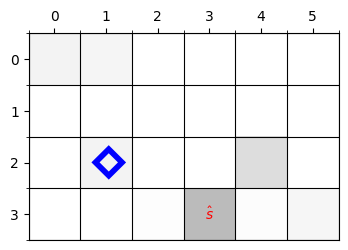

In [14]:
o_seq = [proc.reset()[0]]
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
sest, P_S = dfs_estimator(proc, o_seq)
fig, ax = plt.subplots(figsize=[4, 3])
draw(P_S.reshape(proc.env.G.shape), ax=ax, s=proc.env.s, s_est=sest)
plt.show()

You should also notice it is quite slow. Already we reduced number of runs `N` and length of trajectory `T` significantly. 

Task: Experiment with different `N` and `T` to get a feel for the computational limitations of this approach. 

The lesson here is: this approach is clearly intractable, but the idea of a tree search forms the basis of more advanced methods -- so it's worth studying.

In [15]:
res = evaluate(proc, dfs_estimator, N=10, T=10)
display(pd.DataFrame([res], index=["Optimal Estimator"]))

,average reward per episode,average time per estimator call
Optimal Estimator,0.2,0.000004


### Task 2: Monte Carlo Approximation

Create a Monte Carlo (MC) estimator. There are numerous ways to do this, but all of them involve taking and evaluating samples (the core of any MC approach); the objective is that it be 

1. More accurate than the last-observation estimator, but
2. Faster than exact inference of the optimal estimator.

Again, you should make use of the environmental knowledge; the functions `proc.P_O` and `proc.P_S`. 

In [16]:
def mc_estimator(env, observations, n_particles=10, resample=True):
    """
    Monte Carlo approximation of P(S_t | o_1,...,o_t)
    """

    # TODO
    return np.argmax(P_S), P_S

Check the perfomance. 

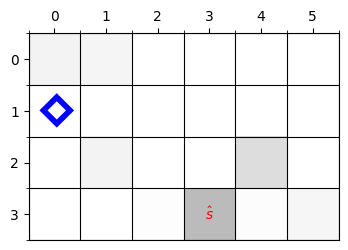

In [17]:
o_seq = [proc.reset()[0]]
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
sest, P_S = dfs_estimator(proc, o_seq)
fig, ax = plt.subplots(figsize=[4, 3])
draw(P_S.reshape(proc.env.G.shape), ax=ax, s=proc.env.s, s_est=sest)
plt.show()

In [18]:
res = evaluate(proc, mc_estimator, N=100, T=10)
display(pd.DataFrame([res], index=["MC Estimator"]))

,average reward per episode,average time per estimator call
MC Estimator,0.1,0.000002


 
## Task 3: Imitation Learning

Suppose now that we don't have knowledge of the environment dynamics. We will instead learn via imitation learning, trying to imitate an expert policy. 

In [19]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

We'll generate a dataset. Notice, we'll use the oracle as the expert, but we could replace it with any of the above experts (the oracle is not available in real life). Of course, the disadvantage of imitation learning is that we cannot expect to outperform the expert.  

In [20]:
def oracle_estimator(proc, observations):
    return proc.env.s, None

In [21]:
def gen_traj(proc, f, T=10):

    o, _ = proc.reset()
    t = 0
    o_seq = [float(o)]
    s_seq = [proc.env.s]

    done = False
    while not done:
        t += 1
        o, terminated, truncated, _ = proc.step()
        o_seq.append(float(o))
        s_seq.append(int(f(proc, o_seq)[0]))
        done = terminated or truncated or t >= T

    return o_seq, s_seq

In [22]:
class EpisodeDataset(Dataset):
    def __init__(self, proc, n_episodes, grid_size):
        self.episodes = []
        for _ in range(n_episodes):
            obs_seq, act_seq = gen_traj(proc, oracle_estimator)
            obs_tensor = torch.tensor(obs_seq, dtype=torch.float32)
            acts = torch.tensor(act_seq, dtype=torch.long)
            #act_one_hot = F.one_hot(acts, num_classes=grid_size*grid_size).float()
            self.episodes.append((obs_tensor, acts))
            #self.episodes.append((obs_tensor, act_one_hot))

    def __len__(self):
        return len(self.episodes)

    def __getitem__(self, idx):
        return self.episodes[idx][0], self.episodes[idx][1]
    
def collate(batch):
    obs, act = zip(*batch)
    obs = [x.unsqueeze(-1) for x in obs]
    obs = torch.nn.utils.rnn.pad_sequence(obs, batch_first=True)

    act = torch.nn.utils.rnn.pad_sequence(act, batch_first=True)
    return obs, act


dataset = EpisodeDataset(proc, n_episodes=1000, grid_size=proc.n_states)

We will be using transformers, which are excellent for sequential modelling. Have a look at the following `class`, which we will use in the following.

In [23]:
class TinyTransformerDecoder(nn.Module):
    def __init__(self, input_dim, output_dim, embedding_dim=16, num_layers=1, num_heads=1, max_seq_len=20):
        super(TinyTransformerDecoder, self).__init__()
        
        self.input_projection = nn.Linear(input_dim, embedding_dim)
        
        self.positional_encoding = self._generate_positional_encoding(max_seq_len, embedding_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=embedding_dim * 2,
            dropout=0.,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.output_projection = nn.Linear(embedding_dim, output_dim)
        
    def _generate_positional_encoding(self, max_seq_len, embedding_dim):
        position = torch.arange(max_seq_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embedding_dim, 2) * (-np.log(10000.0) / embedding_dim))
        pos_encoding = torch.zeros(max_seq_len, embedding_dim)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding
        
    def forward(self, x):
        x_emb = self.input_projection(x)
        
        pos_encoding = self.positional_encoding[:x.size(1), :].to(x.device)
        x_emb = x_emb + pos_encoding

        causal_mask = nn.Transformer.generate_square_subsequent_mask(x.size(1))
        
        x_transformed = self.transformer(x_emb, mask=causal_mask)
        
        output = self.output_projection(x_transformed)
        return output

Specifically, in imitation learning (and in this example), we seek
$$
    \hat s_t = f(o_1, \ldots, o_t)
$$ 
where $f$ the estimator, that maps inputs to a prediction. 

Is it clear by now why we should consider the full history of observations? 

Use the `TinyTransformerDecoder` defined above to complete the Imitation Learning task in the cells below.

We will use Behavioral Cloning, which treat the dataset as a supervised classification task.

In [24]:
input_dim = 1
output_dim = proc.n_states
embedding_dim = 32
num_layers = 2
num_heads = 2
seq_length = 11
batch_size = 256

In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate)
model = TinyTransformerDecoder(input_dim, output_dim, embedding_dim=embedding_dim, num_layers=num_layers, num_heads=num_heads).to(device)

# TODO

Check the results

In [26]:
def cloned_estimator(proc, observations):
    obs = torch.tensor(observations, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
    with torch.no_grad():
        logits = model(obs)
        last_logits = logits[:, -1, :]
        P_S = F.softmax(last_logits, dim=-1).squeeze(0).cpu().numpy()  
    return int(P_S.argmax()), P_S

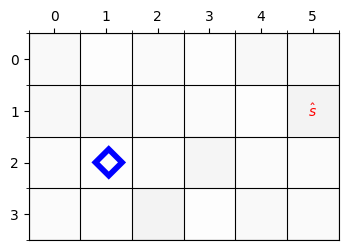

In [27]:
o_seq = [proc.reset()[0]]
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
o_seq.append(proc.step()[0])
sest, P_S = cloned_estimator(proc, o_seq)
fig, ax = plt.subplots(figsize=[4, 3])
draw(P_S.reshape(proc.env.G.shape), ax=ax, s=proc.env.s, s_est=sest)
plt.show()

In [28]:
# Evaluate N episodes, up to a maximum of T timesteps.
res = evaluate(proc, cloned_estimator, N=100, T=10)
display(pd.DataFrame([res], index=["Imitated Estimator"]))

,average reward per episode,average time per estimator call
Imitated Estimator,1.29,0.000761


### Afterthoughts

There are many other tasks we could do with such a framework, for example forecasting (predicting where the mouse will ende up in $\tau$-seconds) -- either in the state space or the observation space. 

In modern applications, the state space $s_t$ is rarely known and rarely a discrete set of numbers; we have to come up with our own *representation* of such a state. 

In this scenario we were only doing predictions; the mouse was the agent, not us. In an agent-based setting (from our perspective; e.g., if we attempt to catch the mouse) our prediction is an action, it will affect the future (e.g., the mouse will either stop moving because we trapped it; or attempt to evade us). That takes us to the realm of sequential decision making. 

Further discussion was given in the lecture.